# Random Forest

In [2]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

PROJECT_ROOT = Path("..").resolve()
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "cleaned_transactions.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE = 500_000  # Use None for full dataset training.

if not DATA_FILE.exists():
    raise FileNotFoundError("Run src/01_process_data.py first to create cleaned_transactions.csv")

## Load Cleaned Data

In [3]:
use_columns = [
    "id", "date", "amount", "use_chip", "merchant_state", "mcc", "errors", "is_fraud"
]

transactions = pd.read_csv(DATA_FILE, usecols=use_columns)
transactions.shape

(8914963, 8)

In [4]:
transactions["is_fraud"].value_counts(normalize=True).mul(100).round(4).rename("percent")

is_fraud
0    99.8505
1     0.1495
Name: percent, dtype: float64

## Feature Engineering

In [5]:
model_data = transactions.copy()

model_data["date"] = pd.to_datetime(model_data["date"], errors="coerce")
model_data["amount_value"] = pd.to_numeric(
    model_data["amount"].astype(str).str.replace("$", "", regex=False),
    errors="coerce",
)
model_data["abs_amount"] = model_data["amount_value"].abs()
model_data["is_negative_amount"] = (model_data["amount_value"] < 0).astype(int)
model_data["hour"] = model_data["date"].dt.hour
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["month"] = model_data["date"].dt.month
model_data["has_error"] = model_data["errors"].notna().astype(int)

feature_columns = [
    "abs_amount",
    "is_negative_amount",
    "hour",
    "day_of_week",
    "month",
    "use_chip",
    "merchant_state",
    "mcc",
    "has_error",
]

X = model_data[feature_columns]
y = model_data["is_fraud"].astype(int)

pd.DataFrame({"feature": feature_columns})

,feature
0,abs_amount
1,is_negative_amount
2,hour
3,day_of_week
4,month
5,use_chip
6,merchant_state
7,mcc
8,has_error


## Optional Stratified Sampling

In [6]:
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(X):
    _, X_model, _, y_model = train_test_split(
        X,
        y,
        test_size=SAMPLE_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )
else:
    X_model = X
    y_model = y

sample_summary = pd.DataFrame(
    {
        "label": ["Non-fraud", "Fraud"],
        "rows": [int((y_model == 0).sum()), int((y_model == 1).sum())],
        "percent": [round((y_model == 0).mean() * 100, 4), round((y_model == 1).mean() * 100, 4)],
    }
)
sample_summary

,label,rows,percent
0,Non-fraud,499252,99.8504
1,Fraud,748,0.1496


## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.25,
    stratify=y_model,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "fraud rows": [int(y_train.sum()), int(y_test.sum())],
        "fraud rate (%)": [round(y_train.mean() * 100, 4), round(y_test.mean() * 100, 4)],
    }
)
split_summary

,split,rows,fraud rows,fraud rate (%)
0,train,375000,561,0.1496
1,test,125000,187,0.1496


## Build Random Forest Pipeline

In [8]:
numeric_features = ["abs_amount", "is_negative_amount", "hour", "day_of_week", "month", "has_error"]
categorical_features = ["use_chip", "merchant_state", "mcc"]

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=16,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_model),
    ]
)
print("Random Forest pipeline created.")

Random Forest pipeline created.


## Train Model

In [9]:
start_time = time.perf_counter()
rf_pipeline.fit(X_train, y_train)
print("Random Forest model trained.")
training_time_seconds = time.perf_counter() - start_time
round(training_time_seconds, 2)

Random Forest model trained.


24.9

## Complexity and Efficiency Notes


In [10]:
encoded_feature_count = len(rf_pipeline.named_steps["preprocess"].get_feature_names_out())
complexity_summary = pd.DataFrame(
    {
        "item": [
            "training rows",
            "test rows",
            "input features before encoding",
            "features after one-hot encoding",
            "number of trees",
            "maximum tree depth",
            "minimum samples per leaf",
            "training time seconds",
        ],
        "value": [
            len(X_train),
            len(X_test),
            len(feature_columns),
            encoded_feature_count,
            rf_pipeline.named_steps["model"].n_estimators,
            rf_pipeline.named_steps["model"].max_depth,
            rf_pipeline.named_steps["model"].min_samples_leaf,
            round(training_time_seconds, 2),
        ],
    }
)
complexity_summary

,item,value
0,training rows,375000.0
1,test rows,125000.0
2,input features before encoding,9.0
3,features after one-hot encoding,262.0
4,number of trees,120.0
5,maximum tree depth,16.0
6,minimum samples per leaf,10.0
7,training time seconds,24.9


## Evaluate Model

In [11]:
y_pred = rf_pipeline.predict(X_test)
y_score = rf_pipeline.predict_proba(X_test)[:, 1]

metrics_summary = pd.DataFrame(
    {
        "model": ["Random Forest"],
        "accuracy": [accuracy_score(y_test, y_pred)],
        "roc_auc": [roc_auc_score(y_test, y_score)],
        "pr_auc": [average_precision_score(y_test, y_score)],
        "training_time_seconds": [training_time_seconds],
    }
)
metrics_summary.round(4)

,model,accuracy,roc_auc,pr_auc,training_time_seconds
0,Random Forest,0.941,0.9651,0.2826,24.8983


In [12]:
print(classification_report(y_test, y_pred, target_names=["Non-fraud", "Fraud"], digits=4))

              precision    recall  f1-score   support

   Non-fraud     0.9998    0.9411    0.9696    124813
       Fraud     0.0222    0.8930    0.0433       187

    accuracy                         0.9410    125000
   macro avg     0.5110    0.9171    0.5065    125000
weighted avg     0.9984    0.9410    0.9682    125000



## Pipeline Readiness Check

In [13]:
readiness_summary = pd.DataFrame({
    "Check": [
        "Training set shape",
        "Testing set shape",
        "Training fraud ratio",
        "Testing fraud ratio",
        "Training fraud count",
        "Testing fraud count"
    ],
    "Output": [
        str(X_train.shape),
        str(X_test.shape),
        round(y_train.mean() * 100, 4),
        round(y_test.mean() * 100, 4),
        int(y_train.sum()),
        int(y_test.sum())
    ]
})

readiness_summary

,Check,Output
0,Training set shape,"(375000, 9)"
1,Testing set shape,"(125000, 9)"
2,Training fraud ratio,0.1496
3,Testing fraud ratio,0.1496
4,Training fraud count,561
5,Testing fraud count,187


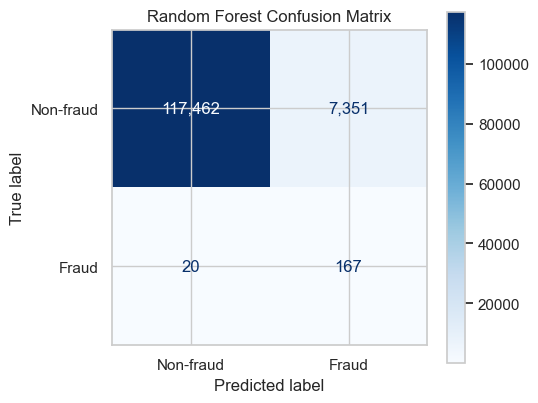

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-fraud", "Fraud"],
    cmap="Blues",
    values_format=",d",
    ax=ax,
)
ax.set_title("Random Forest Confusion Matrix")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_random_forest_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

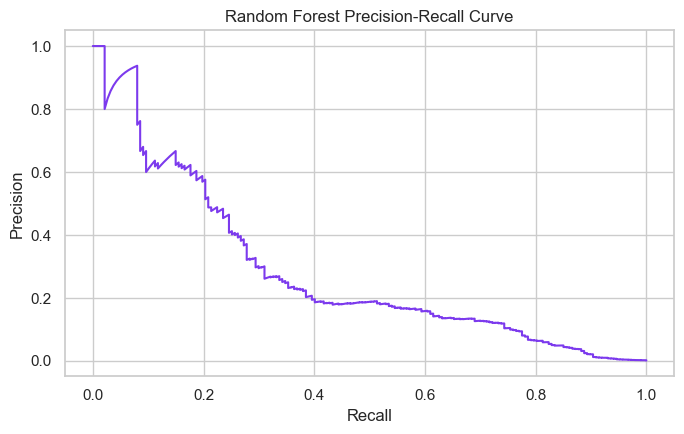

In [15]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recall, precision, color="#7c3aed")
ax.set_title("Random Forest Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_random_forest_precision_recall_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## Threshold Review

In [16]:
threshold_rows = []
for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
    threshold_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "false_positives": fp,
            "false_negatives": fn,
        }
    )

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary.round(4)

,threshold,precision,recall,f1,false_positives,false_negatives
0,0.1,0.0022,1.0000,0.0043,86628,0
1,0.2,0.0063,0.9465,0.0126,27705,10
2,0.3,0.0107,0.9198,0.0212,15865,15
3,0.4,0.0127,0.9037,0.0250,13153,18
4,0.5,0.0222,0.8930,0.0433,7351,20


## Random Forest Threshold Trade-Off Graph


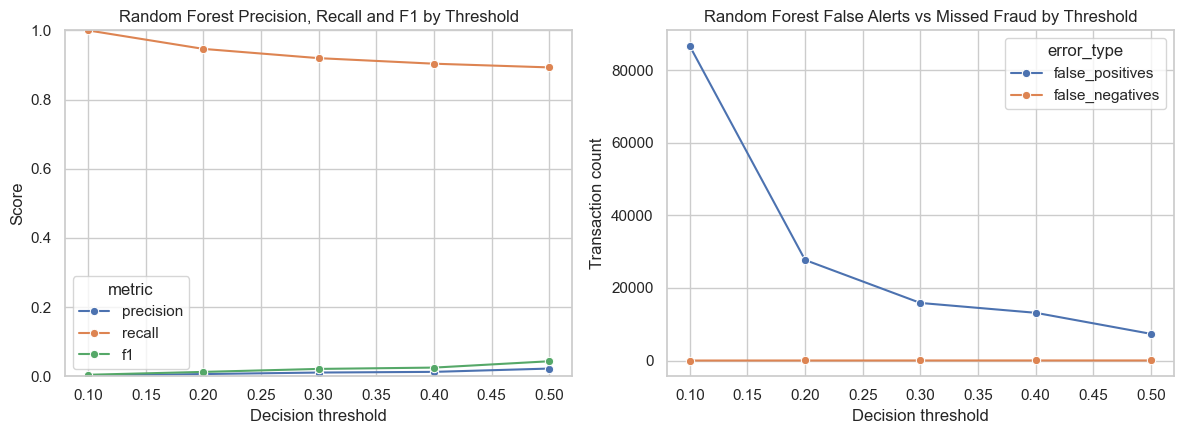

In [17]:
if "threshold_summary" not in globals():
    threshold_rows = []
    for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
        threshold_pred = (y_score >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()
        precision_value = tp / (tp + fp) if (tp + fp) else 0
        recall_value = tp / (tp + fn) if (tp + fn) else 0
        f1_value = 2 * precision_value * recall_value / (precision_value + recall_value) if (precision_value + recall_value) else 0
        threshold_rows.append(
            {
                "threshold": threshold,
                "precision": precision_value,
                "recall": recall_value,
                "f1": f1_value,
                "false_positives": fp,
                "false_negatives": fn,
            }
        )
    threshold_summary = pd.DataFrame(threshold_rows)

threshold_plot = threshold_summary.melt(
    id_vars="threshold",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(data=threshold_plot, x="threshold", y="score", hue="metric", marker="o", ax=axes[0])
axes[0].set_title("Random Forest Precision, Recall and F1 by Threshold")
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)

error_plot = threshold_summary.melt(
    id_vars="threshold",
    value_vars=["false_positives", "false_negatives"],
    var_name="error_type",
    value_name="count",
)
sns.lineplot(data=error_plot, x="threshold", y="count", hue="error_type", marker="o", ax=axes[1])
axes[1].set_title("Random Forest False Alerts vs Missed Fraud by Threshold")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Transaction count")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_random_forest_threshold_tradeoff.png", dpi=160, bbox_inches="tight")
plt.show()

## ROC Curve

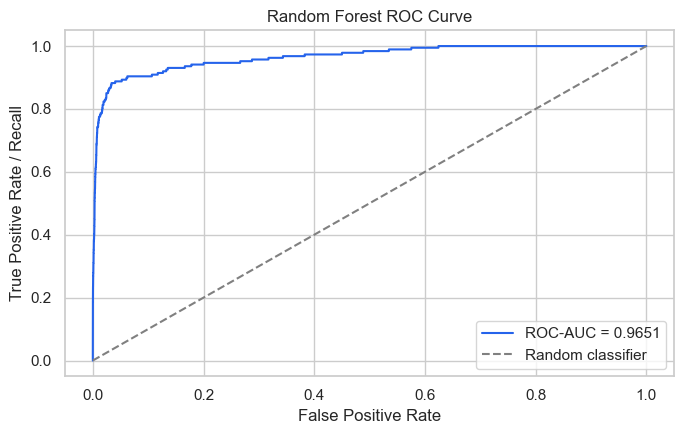

In [18]:
false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(false_positive_rate, true_positive_rate, color="#2563eb", label=f"ROC-AUC = {roc_auc_score(y_test, y_score):.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
ax.set_title("Random Forest ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_random_forest_roc_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## Feature Importance

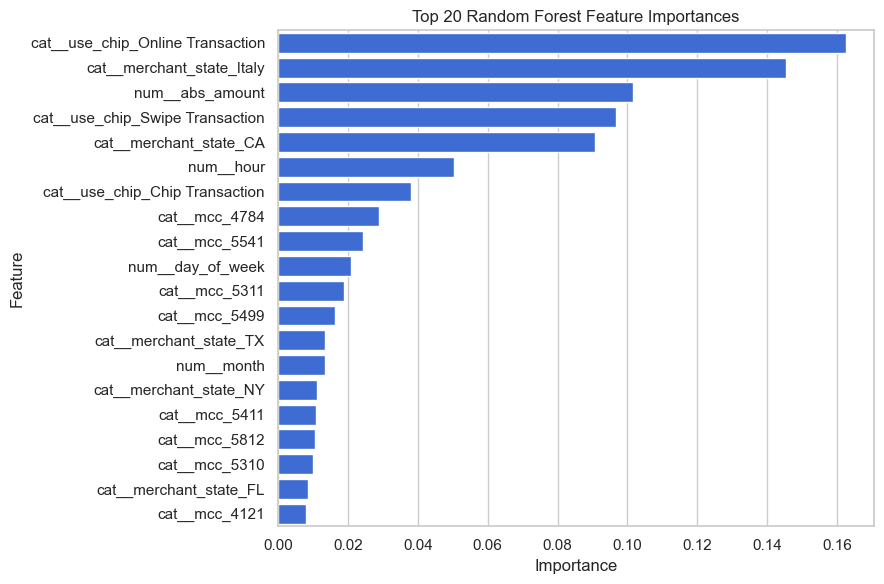

,feature,importance
7,cat__use_chip_Online Transaction,0.162434
61,cat__merchant_state_Italy,0.145492
0,num__abs_amount,0.101635
8,cat__use_chip_Swipe Transaction,0.096684
22,cat__merchant_state_CA,0.090836
2,num__hour,0.050233
6,cat__use_chip_Chip Transaction,0.037948
194,cat__mcc_4784,0.028946
212,cat__mcc_5541,0.024292
3,num__day_of_week,0.020992


In [19]:
feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=feature_importance, y="feature", x="importance", color="#2563eb", ax=ax)
ax.set_title("Top 20 Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_random_forest_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

feature_importance

## Save Model

In [20]:
model_path = MODEL_DIR / "random_forest_fraud_model.joblib"
joblib.dump(rf_pipeline, model_path)
model_path

PosixPath('/Users/zichen/Big-Data-Project/models/random_forest_fraud_model.joblib')